# CSI4142 Assignment 1 — Dataset 2: Exploratory Data Analysis

**Martin Patrouchev**(300286634) | **Peter Bou-Farah**(300295193)

---

## Introduction
This notebook presents an exploratory data analysis (EDA) of the S&P 500 Constituents Financials dataset. We summarize central tendency and dispersion, and use univariate and bivariate visualizations to uncover insights about sectors, valuation, and financial metrics.

This data set would be great for analysts, investors, or students interested in understanding the composition and financial characteristics of S&P 500 companies.

## Dataset Description

- **Name:** S&P 500 Constituents Financials  
- **Source:** [GitHub - s-and-p-500-companies-financials](https://github.com/datasets/s-and-p-500-companies-financials)  
- **Purpose:** Financial and sector data for S&P 500 index constituents (valuation, earnings, dividends, market cap).

**Shape:** The dataset has multiple rows (one per company) and 14 columns.

**Features (subset used in this analysis):**

| Feature | Type | Description |
|--------|------|-------------|
| Symbol | Categorical | Stock ticker |
| Name | Categorical | Company name |
| Sector | Categorical | Industry sector (e.g. Biotechnology, Health Care) |
| Price | Numerical | Stock price |
| Price/Earnings | Numerical | P/E ratio |
| Dividend Yield | Numerical | Dividend yield (decimal) |
| Earnings/Share | Numerical | EPS |
| 52 Week Low / High | Numerical | 52-week price range |
| Market Cap | Numerical | Market capitalization ($) |
| EBITDA | Numerical | Earnings before interest, taxes, depreciation, amortization ($) |
| Price/Sales, Price/Book | Numerical | Valuation ratios |

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (public URL — no local download required)
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies-financials/main/data/constituents-financials.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (503, 14)


,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M,Industrial Conglomerates,152.20,21.286713,0.0199,7.15,75.652176,155.00,8.329418e+10,8.117000e+09,2.552062,17.855467,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A. O. Smith,Building Products,67.30,18.539946,0.0196,3.63,66.760000,92.45,9.758165e+09,8.091000e+08,2.506078,5.091157,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care Equipment,127.93,16.744764,0.0202,7.64,99.710000,129.85,2.218895e+11,1.082500e+10,5.383446,5.575749,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie,Biotechnology,183.90,64.300700,0.0373,2.86,153.580000,207.32,3.249770e+11,2.563000e+10,5.851963,53.882210,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture,IT Consulting & Other Services,384.95,32.294464,0.0170,11.92,278.690000,387.51,2.407785e+11,1.106591e+10,3.710195,8.508687,http://www.sec.gov/cgi-bin/browse-edgar?action...


---

## Insight 1 (r1) — Histogram of Price/Earnings

**Insight:** P/E ratios are right-skewed; most S&P 500 constituents have P/E between about 10 and 30, with a long tail of higher valuations.

**Analysis type:** Univariate, numerical — histogram for dispersion of a numerical variable.

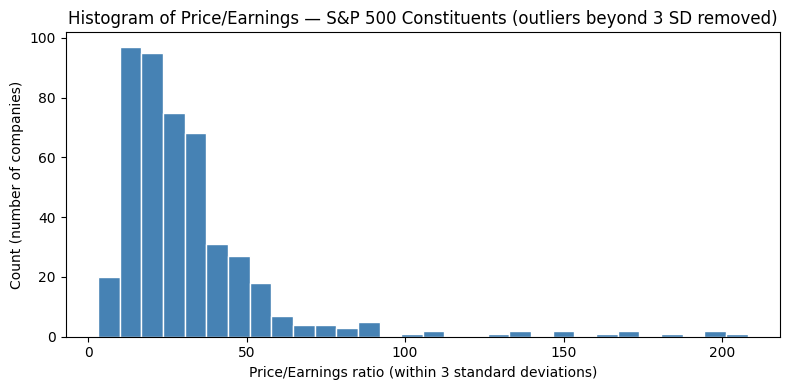

In [ ]:
# For visualization purposes, we remove outliers beyond 3 standard deviations
pe = df["Price/Earnings"]
mean_pe = pe.mean()
std_pe = pe.std()
pe_clean = pe[(pe > mean_pe - 3 * std_pe) & (pe < mean_pe + 3 * std_pe)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pe_clean, bins=30, edgecolor="white", color="steelblue")
ax.set_xlabel("Price/Earnings ratio (within 3 standard deviations)")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Histogram of Price/Earnings — S&P 500 Constituents (outliers beyond 3 SD removed)")
plt.tight_layout()
plt.show()

## Insight 2 (r2) — Countplot of Ticker Symbol Length

**Insight:** Most S&P 500 tickers have 2–4 letters; the countplot shows how many constituents fall into each symbol-length category (number of letters in the ticker).

**Analysis type:** Univariate, categorical — countplot for distribution among category values (symbol length derived from ticker).

/var/folders/cn/30r645x97_v9fhysj0nw00dr0000gn/T/ipykernel_36533/1621876779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Symbol_Length", palette="viridis", ax=ax)


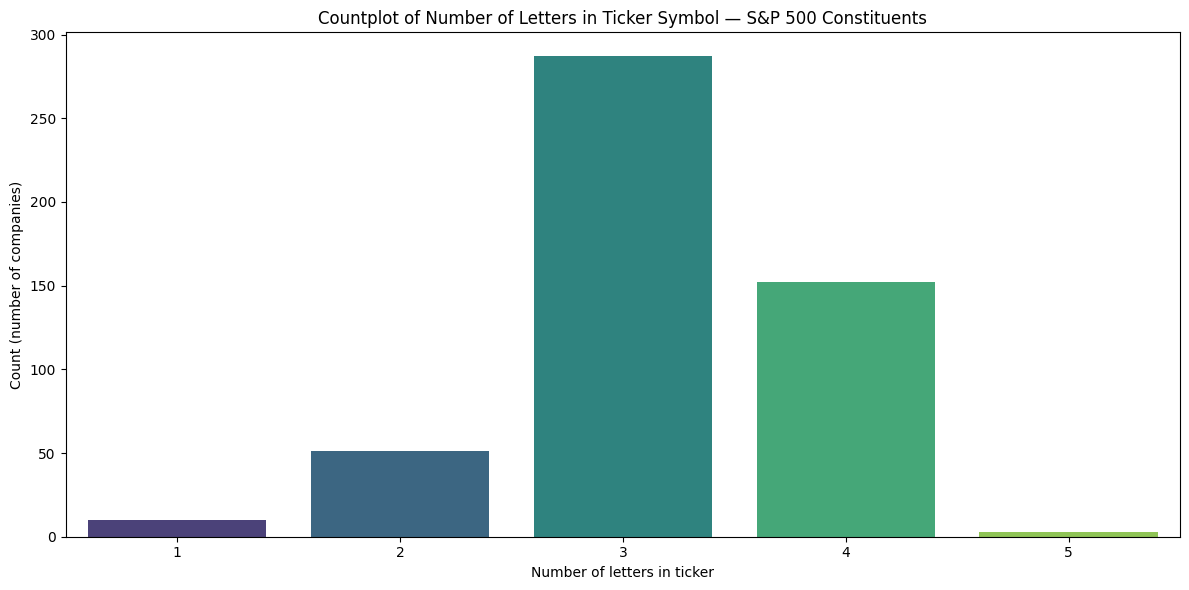

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))  # Adjust size appropriately for this plot
df['Symbol_Length'] = df['Symbol'].str.len()
sns.countplot(data=df, x="Symbol_Length", palette="viridis", ax=ax)
ax.set_xlabel("Number of letters in ticker")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Countplot of Number of Letters in Ticker Symbol — S&P 500 Constituents")
plt.tight_layout()
plt.show()

## Insight 3 (r3) — Grouped Sectors into Macro Categories

**Insight:** When sectors are grouped into macro categories (Technology, Health, Financials, Consumer, Industrial & Other), Technology and Health together account for a large share of constituents.

**Analysis type:** Univariate, categorical — grouped-data countplot (grouping explained below).

/var/folders/cn/30r645x97_v9fhysj0nw00dr0000gn/T/ipykernel_36533/1683287860.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="MacroSector", order=order, ax=ax, palette="Set2")


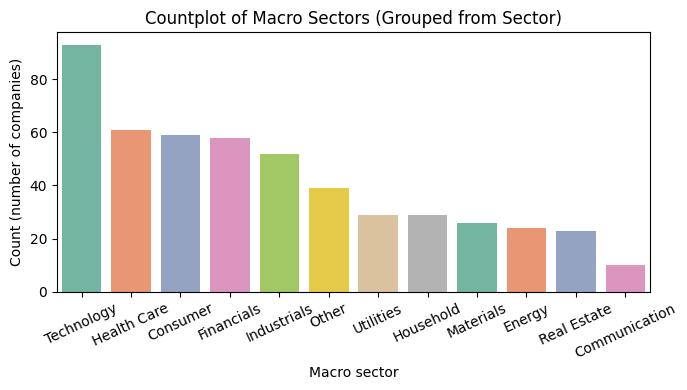

In [23]:
def map_sector(s):
    s_lower = str(s).lower()

    if any(k in s_lower for k in [
        "software", "it ", "semiconductor", "technology",
        "data processing", "internet services",
        "electronic", "communications equipment",
        "systems software", "application software",
        "technology hardware", "semiconductor materials",
        "interactive media", "transaction & payment processing"
    ]):
        return "Technology"

    if any(k in s_lower for k in [
        "health", "biotechnology", "pharmaceutical",
        "life sciences", "health care", "medical",
        "managed health", "health care equipment",
        "health care services", "health care supplies"
    ]):
        return "Health Care"

    if any(k in s_lower for k in [
        "bank", "insurance", "financial",
        "asset management", "investment banking",
        "capital markets", "consumer finance",
        "reinsurance", "brokerage", "exchanges"
    ]):
        return "Financials"

    if any(k in s_lower for k in [
        "retail", "automobile", "automotive",
        "hotels", "resorts", "casinos",
        "restaurants", "leisure",
        "apparel", "luxury", "footwear",
        "home improvement", "home furnishings",
        "movies", "entertainment"
    ]):
        return "Consumer"

    if any(k in s_lower for k in [
        "food", "beverages", "brewers",
        "distillers", "tobacco",
        "household products",
        "personal care",
        "packaged foods",
        "drug retail",
        "consumer staples"
    ]):
        return "Household"

    if any(k in s_lower for k in [
        "oil & gas", "energy",
        "exploration & production",
        "refining", "storage & transportation",
        "integrated oil", "oil & gas equipment"
    ]):
        return "Energy"

    if any(k in s_lower for k in [
        "electric utilities", "gas utilities",
        "water utilities", "multi-utilities",
        "independent power producers"
    ]):
        return "Utilities"

    if any(k in s_lower for k in [
        "reit", "real estate",
        "office reits", "data center reits",
        "industrial reits", "retail reits",
        "residential reits", "self-storage",
        "timber reits", "hotel & resort reits"
    ]):
        return "Real Estate"

    if any(k in s_lower for k in [
        "chemicals", "specialty chemicals",
        "commodity chemicals",
        "metals", "steel", "copper",
        "gold", "paper", "plastic",
        "containers", "construction materials",
        "fertilizers", "agricultural chemicals"
    ]):
        return "Materials"

    if any(k in s_lower for k in [
        "industrial", "machinery",
        "aerospace", "defense",
        "construction", "engineering",
        "transportation", "rail",
        "air freight", "logistics",
        "distributors", "trading companies",
        "environmental services"
    ]):
        return "Industrials"

    if any(k in s_lower for k in [
        "telecommunication", "wireless",
        "cable", "satellite",
        "broadcasting", "publishing",
        "interactive home entertainment"
    ]):
        return "Communication"

    return "Other"

df["MacroSector"] = df["Sector"].apply(map_sector)
fig, ax = plt.subplots(figsize=(7, 4))
order = df["MacroSector"].value_counts().index
sns.countplot(data=df, x="MacroSector", order=order, ax=ax, palette="Set2")
ax.set_xlabel("Macro sector")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Countplot of Macro Sectors (Grouped from Sector)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Insight 4 (r4) — Boxplot of Price/Earnings by Macro Sector

**Insight:** P/E ratios differ by macro sector, such as some sectors (e.g., technology) show higher median P/E and wider dispersion than others.

**Analysis type:** Bivariate, numerical/categorical — numerical variable (Price/Earnings) distribution by categorical (Macro Sector).

/var/folders/cn/30r645x97_v9fhysj0nw00dr0000gn/T/ipykernel_36533/3788048133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="MacroSector", y="pe_clean", order=order, ax=ax, palette="Set2")


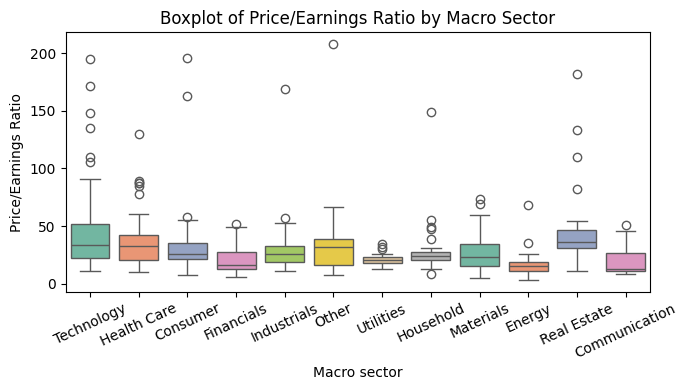

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df["MacroSector"].value_counts().index
# For visualization purposes, we remove outliers beyond 3 standard deviations
df["pe_clean"] = df["Price/Earnings"].where(
    (df["Price/Earnings"] > df["Price/Earnings"].mean() - 3 * df["Price/Earnings"].std()) &
    (df["Price/Earnings"] < df["Price/Earnings"].mean() + 3 * df["Price/Earnings"].std())
)
sns.boxplot(data=df, x="MacroSector", y="pe_clean", order=order, ax=ax, palette="Set2")
ax.set_xlabel("Macro sector")
ax.set_ylabel("Price/Earnings Ratio")
ax.set_title("Boxplot of Price/Earnings Ratio by Macro Sector")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Insight 5 (r5) — Dividend-Paying vs Non-Paying (Binary)

**Insight:** Most of the S&P 500 companies pay a dividend; with some sectors  having almost all their companies pay dividends (e.g., Utilities).

**Analysis type:** Bivariate, categorical/categorical — comparing two categories (sector vs dividend yield).

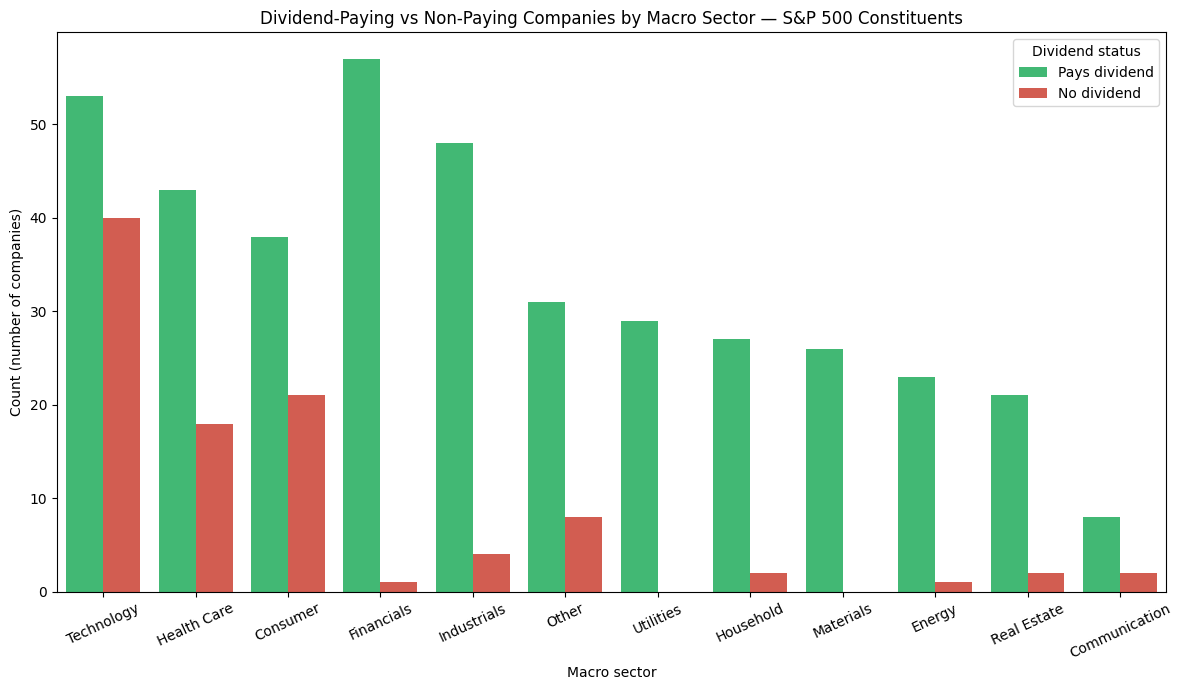

In [26]:
df["DividendPayer"] = (df["Dividend Yield"] > 0).map({True: "Pays dividend", False: "No dividend"})

fig, ax = plt.subplots(figsize=(12, 7))
sns.countplot(
    data=df,
    x="MacroSector",
    hue="DividendPayer",
    order=df["MacroSector"].value_counts().index,
    palette=["#2ecc71", "#e74c3c"]
)
ax.set_ylabel("Count (number of companies)")
ax.set_xlabel("Macro sector")
ax.set_title("Dividend-Paying vs Non-Paying Companies by Macro Sector — S&P 500 Constituents")
ax.legend(title="Dividend status", loc="best")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Insight 6 (r6) — Ordered Countplot of Macro Sector by Symbol Length

**Insight:** Ordering macro sectors by total count and breaking down by ticker symbol length shows how some sectors prefer 4 letter ticker lenghs (e.g., technology) compare to others.

**Analysis type:** Bivariate, categorical — countplot by sector and explicit order (by count), with a second categorical (symbol length) as hue.

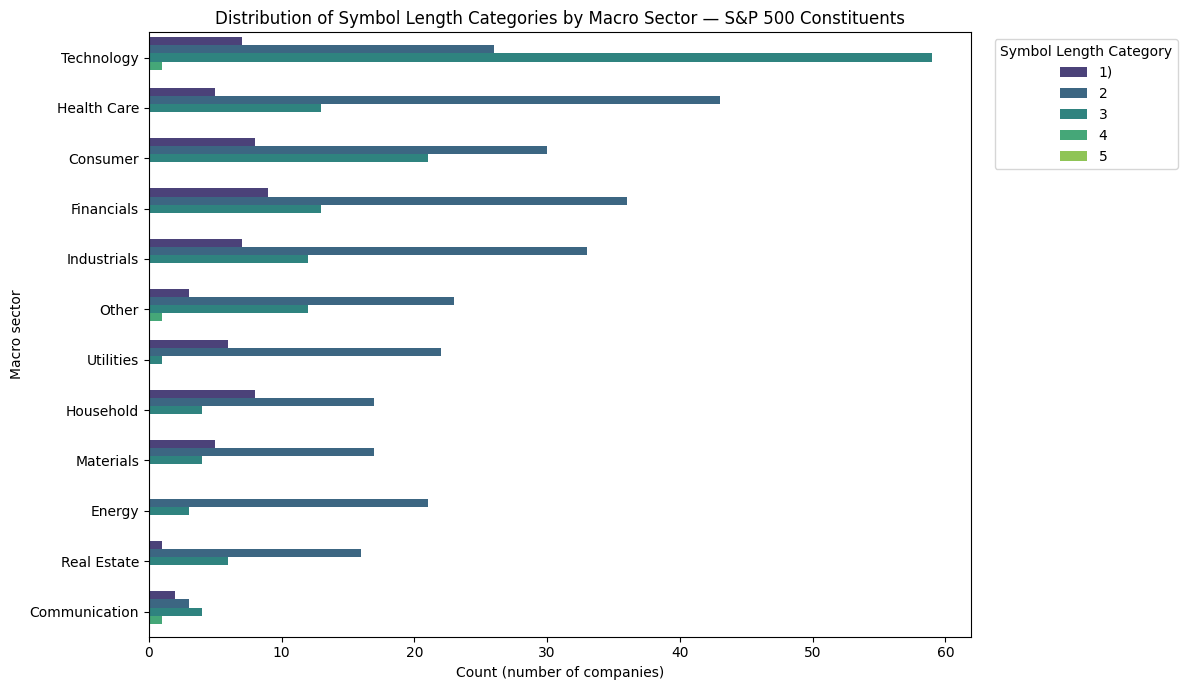

In [27]:
symbol_length = df["Symbol"].str.len()
bin_labels = ["1)", "2", "3", "4", "5"]
df["SymbolLengthCat"] = pd.cut(symbol_length, bins=[0,2,3,4,5,99], labels=bin_labels, right=True, include_lowest=True)

macro_order = df["MacroSector"].value_counts().index
length_order = bin_labels

fig, ax = plt.subplots(figsize=(12, 7))
sns.countplot(
    data=df,
    y="MacroSector",
    hue="SymbolLengthCat",
    order=macro_order,
    hue_order=length_order,
    palette="viridis"
)
ax.set_xlabel("Count (number of companies)")
ax.set_ylabel("Macro sector")
ax.set_title("Distribution of Symbol Length Categories by Macro Sector — S&P 500 Constituents")
ax.legend(title="Symbol Length Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Insight 7 (r7) — Sector Distribution by Market Cap Bins

**Insight:** Sector composition varies across market-cap size bins; larger-cap bins is dominated by sectors such as technology with some sectors not having a company with a market cap over 500B+ (e.g., Energy).

**Analysis type:** Bivariate, categorical/numerical — categorical (Sector) distribution among bins of a numerical feature (Market Cap).

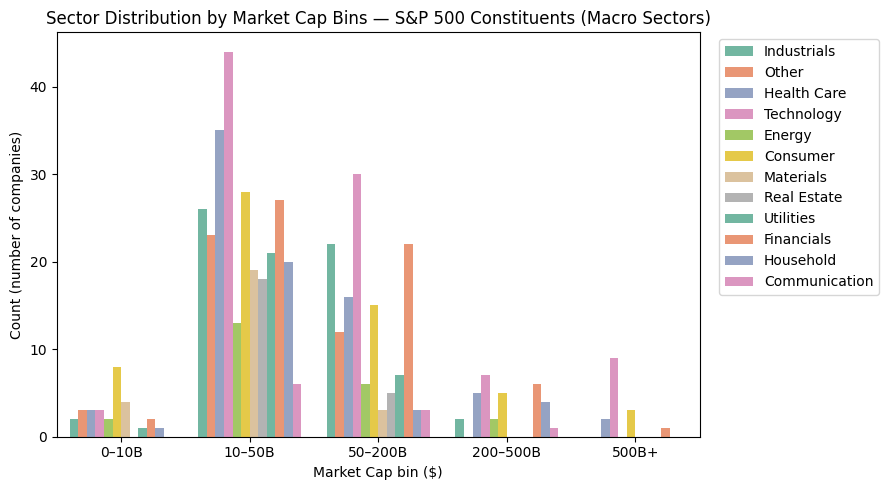

In [28]:
bins = [0, 10e9, 50e9, 200e9, 500e9, float("inf")]
labels = ["0–10B", "10–50B", "50–200B", "200–500B", "500B+"]
df["MarketCapBin"] = pd.cut(df["Market Cap"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="MarketCapBin", hue="MacroSector", ax=ax, palette="Set2")
ax.set_xlabel("Market Cap bin ($)")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Sector Distribution by Market Cap Bins — S&P 500 Constituents (Macro Sectors)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Insight 8 (r8) — Scatterplot: Market Cap vs EBITDA

**Insight:** Market Cap and EBITDA are positively correlated; larger companies tend to have both higher market cap and higher EBITDA.

**Analysis type:** Bivariate, numerical/numerical — scatterplot to highlight correlation.

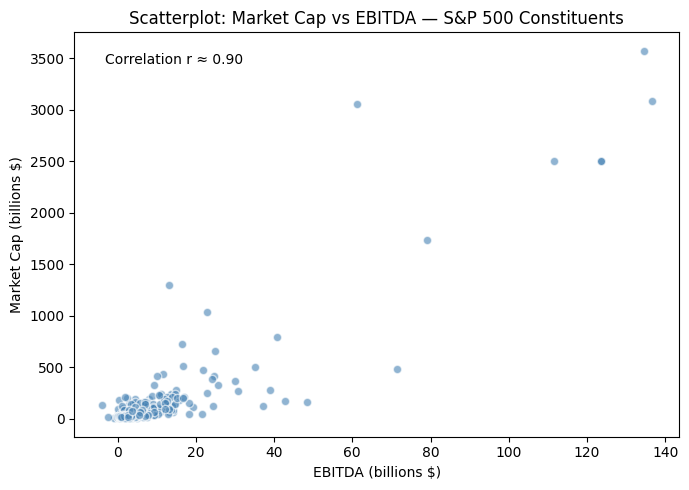

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["EBITDA"] / 1e9, df["Market Cap"] / 1e9, alpha=0.6, c="steelblue", edgecolors="white")
ax.set_xlabel("EBITDA (billions $)")
ax.set_ylabel("Market Cap (billions $)")
ax.set_title("Scatterplot: Market Cap vs EBITDA — S&P 500 Constituents")
r = df[["Market Cap", "EBITDA"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Correlation r ≈ {r:.2f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
plt.tight_layout()
plt.show()

## Insight 9 — Dividend Yield by Macro Sector (Paying Companies)

**Insight:** Among dividend payers, median dividend yield varies by macro sector; some sectors show higher yields (e.g., Utilities).

**Analysis type:** Bivariate, numerical/categorical — boxplot of Dividend Yield (%) by Macro Sector for companies that pay a dividend.

/var/folders/cn/30r645x97_v9fhysj0nw00dr0000gn/T/ipykernel_36533/422371142.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


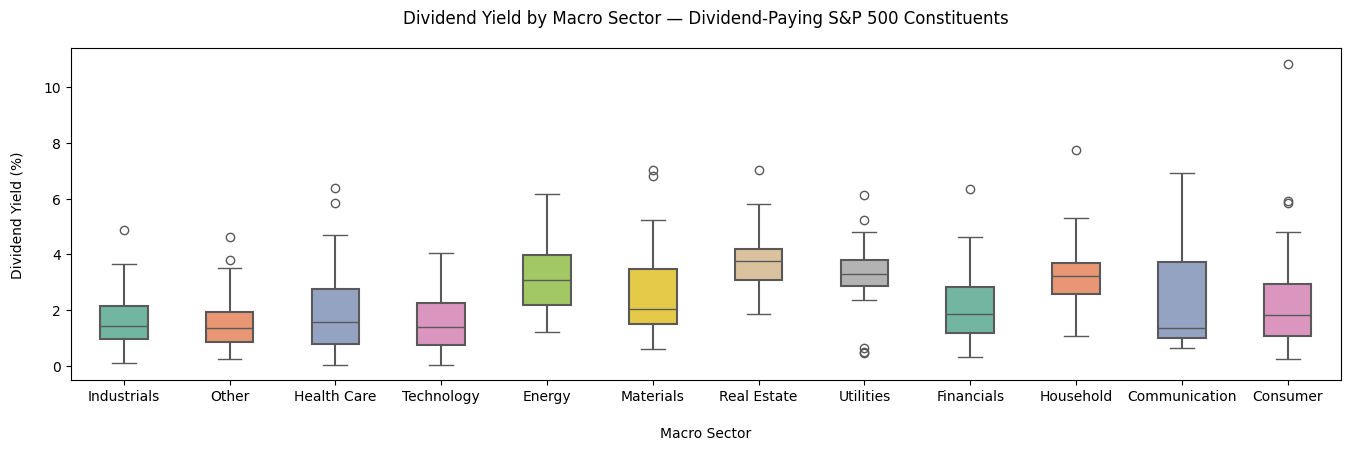

In [30]:
df["Dividend Yield (%)"] = df["Dividend Yield"] * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df[df["Dividend Yield"] > 0],
    x="MacroSector",
    y="Dividend Yield (%)",
    ax=ax,
    palette="Set2",
    width=0.45,
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
)

ax.set_xlabel("Macro Sector", labelpad=16)
ax.set_ylabel("Dividend Yield (%)", labelpad=14)
ax.set_title("Dividend Yield by Macro Sector — Dividend-Paying S&P 500 Constituents", pad=18)
plt.tight_layout(pad=2.5)    
plt.show()

## Insight 10 — 52-Week Volatility Across Macro Sectors

**Insight:** 52-week volatility (measured as (52 Week High - 52 Week Low) / Price) varies significantly across macro sectors. Some sectors, such as Technology and Communication Services, tend to exhibit a wider range and higher median volatility, while others like Utilities and Consumer Staples generally show lower volatility. 

**Analysis type:** Bivariate, numerical/categorical — boxplot of 52-week volatility by Macro Sector (filtered to exclude extreme outliers).

/var/folders/cn/30r645x97_v9fhysj0nw00dr0000gn/T/ipykernel_36533/3785749510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


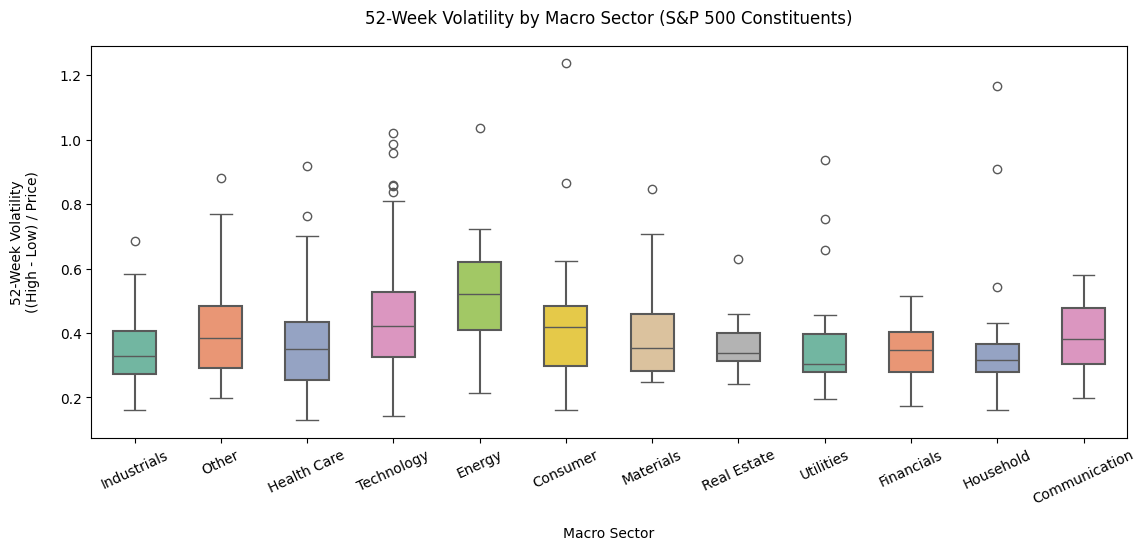

In [22]:
# Calculate 52-week volatility as (52 Week High - 52 Week Low) / Price
df["Volatility"] = (df["52 Week High"] - df["52 Week Low"]) / df["Price"]
vol_mean = df["Volatility"].mean()
vol_std = df["Volatility"].std()
# Filter to within 3 standard deviations for the boxplot
vol_mask = (df["Volatility"] >= vol_mean - 3 * vol_std) & (df["Volatility"] <= vol_mean + 3 * vol_std)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df[vol_mask],
    x="MacroSector",
    y="Volatility",
    ax=ax,
    palette="Set2",
    width=0.5,
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
)
ax.set_xlabel("Macro Sector", labelpad=14)
ax.set_ylabel("52-Week Volatility\n((High - Low) / Price)", labelpad=14)
ax.set_title("52-Week Volatility by Macro Sector (S&P 500 Constituents)", pad=16)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(pad=2.5)
plt.show()

---

## Conclusion

This EDA of the S&P 500 Constituents Financials dataset illustrated sector composition, ticker symbol length distribution, valuation (P/E, Price), dividend behavior, and the relationship between Market Cap and EBITDA. The required analysis types (r1–r8) were covered via histograms, countplots (univariate symbol length; grouped macro sectors; ordered macro sector by symbol length), boxplots (P/E by macro sector), binary comparison (dividend payers by sector), sector-by–market-cap bins, and a scatterplot. The dataset is suitable for further modeling (e.g. sector or size-based analysis) and is fully loaded from a public URL for reproducibility.

---

## References

- Dataset: [S&P 500 Companies Financials](https://github.com/datasets/s-and-p-500-companies-financials) (GitHub).
- Python: [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) (Jake VanderPlas).
- Visualization: [Matplotlib](https://matplotlib.org/), [Seaborn](https://seaborn.pydata.org/) documentation.
- **ChatGPT (OpenAI):** Used to design the sector-grouping approach for the univariate categorical grouped analysis (Insight 3). Prompt: For a Univariate Categorical Grouped analysis with a function (`map_sector`) to group the dataset’s many unique sectors into broader macro categories (e.g. Technology, Health, Financials, Consumer, Industrial & Other), given the full list of unique sectors.